
=== TRAIN ===
truck        | 이미지 1802장 | bbox  2051개 | bbox 면적(px^2) 평균=4948.9, 표준편차=5273.9, 최소=231.0, 최대=50778.0, 중앙값=3185.0
motorcycle   | 이미지 2895장 | bbox  5085개 | bbox 면적(px^2) 평균=714.6, 표준편차=545.4, 최소=70.0, 최대=5547.0, 중앙값=528.0
car          | 이미지 4053장 | bbox  7931개 | bbox 면적(px^2) 평균=1841.2, 표준편차=1919.0, 최소=77.0, 최대=15244.0, 중앙값=1131.0


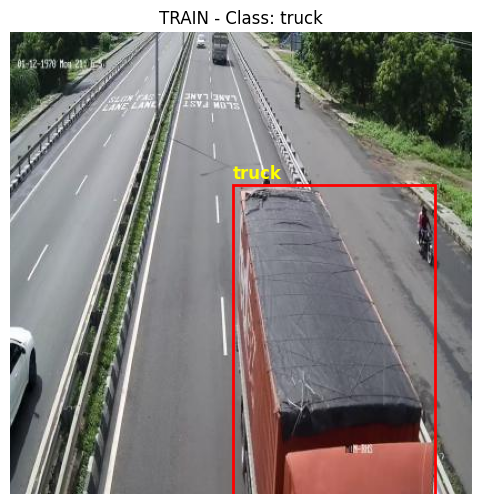

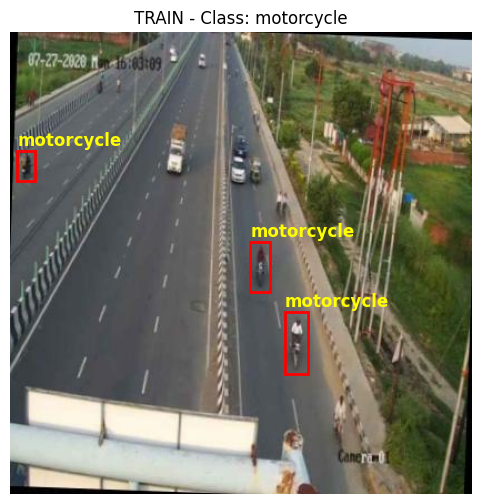

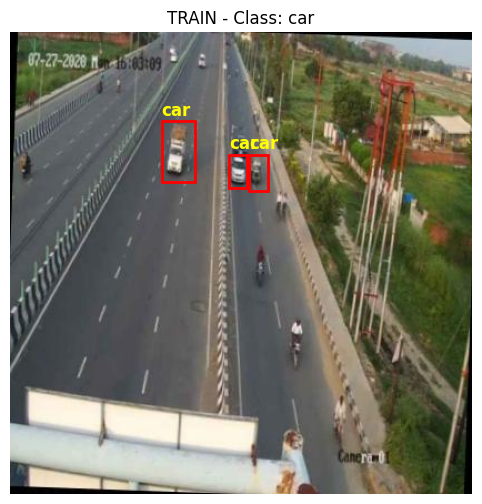


=== VALID ===
truck        | 이미지  520장 | bbox   589개 | bbox 면적(px^2) 평균=5150.5, 표준편차=5366.4, 최소=170.0, 최대=42570.0, 중앙값=3105.0
motorcycle   | 이미지  802장 | bbox  1438개 | bbox 면적(px^2) 평균=722.1, 표준편차=544.0, 최소=101.5, 최대=5916.0, 중앙값=540.0
car          | 이미지 1173장 | bbox  2377개 | bbox 면적(px^2) 평균=1838.4, 표준편차=1908.1, 최소=120.0, 최대=17160.0, 중앙값=1174.5


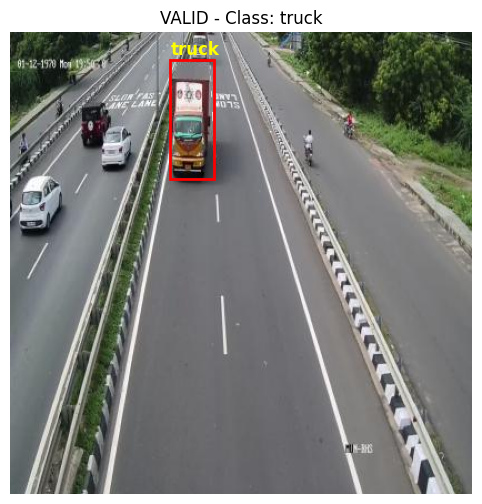

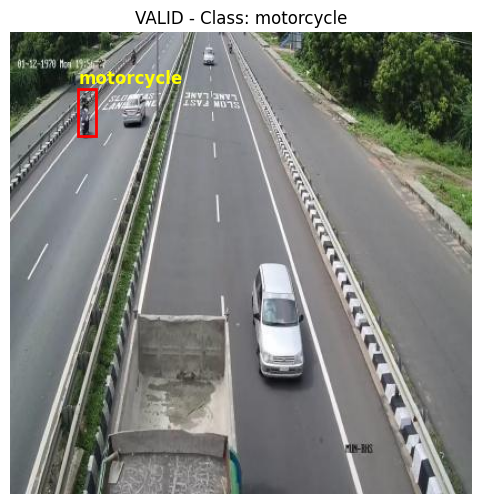

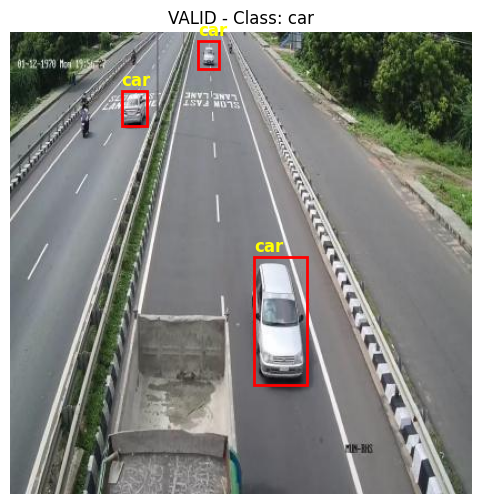


=== TEST ===
truck        | 이미지  281장 | bbox   318개 | bbox 면적(px^2) 평균=5265.4, 표준편차=5823.2, 최소=153.0, 최대=35427.0, 중앙값=3229.0
motorcycle   | 이미지  427장 | bbox   742개 | bbox 면적(px^2) 평균=701.8, 표준편차=547.4, 최소=132.0, 최대=5292.0, 중앙값=520.0
car          | 이미지  561장 | bbox  1092개 | bbox 면적(px^2) 평균=1894.8, 표준편차=1952.9, 최소=117.0, 최대=13892.0, 중앙값=1188.0


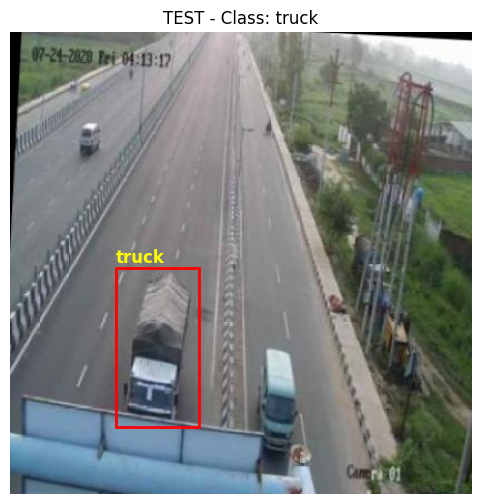

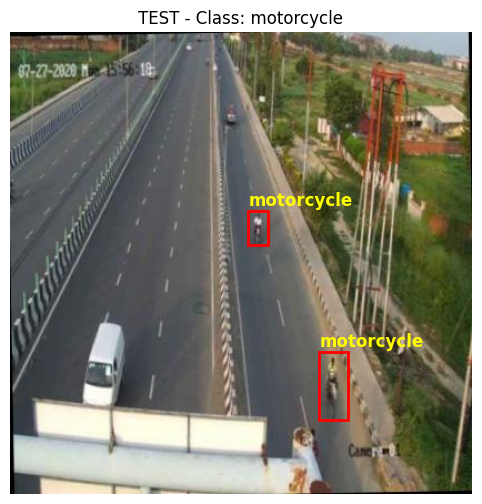

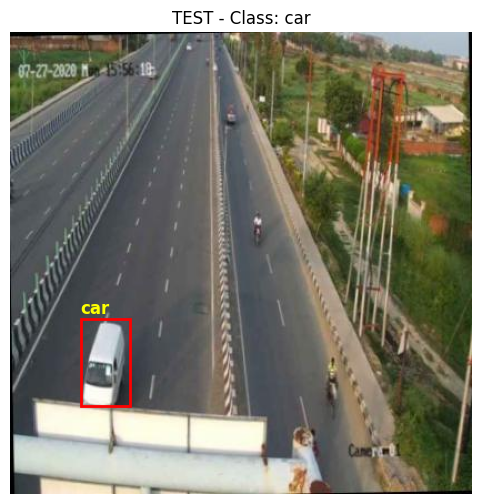


=== 요약 테이블 ===
   split       class  images  bboxes    bbox_mean     bbox_std  bbox_min  \
0  train       truck    1802    2051  4948.913701  5273.928482     231.0   
1  train  motorcycle    2895    5085   714.550147   545.384979      70.0   
2  train         car    4053    7931  1841.190014  1918.968991      77.0   
3  valid       truck     520     589  5150.497029  5366.414958     170.0   
4  valid  motorcycle     802    1438   722.051113   543.984489     101.5   
5  valid         car    1173    2377  1838.355911  1908.094577     120.0   
6   test       truck     281     318  5265.419025  5823.198980     153.0   
7   test  motorcycle     427     742   701.762129   547.445673     132.0   
8   test         car     561    1092  1894.811813  1952.859916     117.0   

   bbox_max  bbox_median  
0   50778.0       3185.0  
1    5547.0        528.0  
2   15244.0       1131.0  
3   42570.0       3105.0  
4    5916.0        540.0  
5   17160.0       1174.5  
6   35427.0       3229.0  
7    52

In [5]:
import json, os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import defaultdict
from PIL import Image
import numpy as np
import pandas as pd

# ===== 경로 설정 =====
base_dir = "/mnt/c/DPSlab/qcnn/Highway-classification-1"
splits = ["train", "valid", "test"]

# 대상 클래스
target_classes = {"car", "motorcycle", "truck"}

# 최종 결과 저장
results = []

# ===== 각 split 처리 =====
for split in splits:
    ann_path = os.path.join(base_dir, split, "_annotations.coco.json")
    img_root = os.path.join(base_dir, split)

    if not os.path.exists(ann_path):
        print(f"[경고] {split}에 어노테이션 없음")
        continue

    with open(ann_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    categories = {c["id"]: c["name"] for c in data["categories"]}
    annotations = data["annotations"]
    images = {img["id"]: img for img in data["images"]}

    # 클래스별 통계
    stats = defaultdict(lambda: {"images": set(), "bboxes": 0, "sizes": []})
    for ann in annotations:
        cat = categories[ann["category_id"]]
        if cat not in target_classes:
            continue
        stats[cat]["images"].add(ann["image_id"])
        stats[cat]["bboxes"] += 1
        _, _, w, h = ann["bbox"]
        stats[cat]["sizes"].append(w * h)

    print(f"\n=== {split.upper()} ===")
    for cat in target_classes:
        sizes = np.array(stats[cat]["sizes"])
        if len(sizes) > 0:
            mean_size = sizes.mean()
            std_size = sizes.std()
            min_size = sizes.min()
            max_size = sizes.max()
            median_size = np.median(sizes)
        else:
            mean_size = std_size = min_size = max_size = median_size = 0

        print(f"{cat:12s} | 이미지 {len(stats[cat]['images']):4d}장 "
              f"| bbox {stats[cat]['bboxes']:5d}개 "
              f"| bbox 면적(px^2) 평균={mean_size:.1f}, 표준편차={std_size:.1f}, "
              f"최소={min_size:.1f}, 최대={max_size:.1f}, 중앙값={median_size:.1f}")

        # 결과 저장
        results.append({
            "split": split,
            "class": cat,
            "images": len(stats[cat]["images"]),
            "bboxes": stats[cat]["bboxes"],
            "bbox_mean": mean_size,
            "bbox_std": std_size,
            "bbox_min": min_size,
            "bbox_max": max_size,
            "bbox_median": median_size,
        })

    # ===== 시각화 (split마다 클래스별 샘플 한 장) =====
    for cat in target_classes:
        if not stats[cat]["images"]:
            continue
        img_id = next(iter(stats[cat]["images"]))  # 첫 번째 이미지
        img_info = images[img_id]
        img_path = os.path.join(img_root, img_info["file_name"])

        if not os.path.exists(img_path):
            print(f"[경고] 이미지 없음: {img_path}")
            continue

        img = Image.open(img_path).convert("RGB")
        fig, ax = plt.subplots(1, figsize=(8, 6))
        ax.imshow(img)

        for ann in annotations:
            if ann["image_id"] == img_id and categories[ann["category_id"]] == cat:
                x, y, w, h = ann["bbox"]
                rect = patches.Rectangle((x, y), w, h, linewidth=2,
                                         edgecolor="red", facecolor="none")
                ax.add_patch(rect)
                ax.text(x, y-5, cat, color="yellow", fontsize=12, weight="bold")

        ax.set_title(f"{split.upper()} - Class: {cat}")
        ax.axis("off")
        plt.show()

# ===== DataFrame 요약 =====
df = pd.DataFrame(results)
print("\n=== 요약 테이블 ===")
print(df)

In [66]:
import json, os
from collections import defaultdict

reduced_base = "/mnt/c/DPSlab/qcnn/Highway-classification-1-downsampled"
splits = ["train", "valid", "test"]
target_classes = {"car", "motorcycle", "truck"}

for split in splits:
    ann_path = os.path.join(reduced_base, split, "_annotations.coco.json")
    if not os.path.exists(ann_path):
        print(f"[경고] {split} 없음")
        continue

    with open(ann_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    categories = {c["id"]: c["name"] for c in data["categories"]}
    annotations = data["annotations"]

    stats = defaultdict(lambda: {"images": set(), "bboxes": 0})
    for ann in annotations:
        cat = categories[ann["category_id"]]
        if cat not in target_classes:
            continue
        stats[cat]["images"].add(ann["image_id"])
        stats[cat]["bboxes"] += 1

    print(f"\n=== {split.upper()} (다운샘플 후) ===")
    for cat in target_classes:
        print(f"{cat:12s} | 이미지 {len(stats[cat]['images']):4d}장 "
              f"| bbox {stats[cat]['bboxes']:5d}개")


=== TRAIN (다운샘플 후) ===
truck        | 이미지  897장 | bbox   981개
motorcycle   | 이미지  751장 | bbox   976개
car          | 이미지  712장 | bbox   991개

=== VALID (다운샘플 후) ===
truck        | 이미지  193장 | bbox   212개
motorcycle   | 이미지  270장 | bbox   359개
car          | 이미지  325장 | bbox   446개

=== TEST (다운샘플 후) ===
truck        | 이미지  109장 | bbox   116개
motorcycle   | 이미지  148장 | bbox   196개
car          | 이미지  179장 | bbox   245개


In [67]:
import json, os
import numpy as np

base = "/mnt/c/DPSlab/qcnn/Highway-classification-1"   # 원본 데이터셋
splits = ["train", "valid", "test"]

for split in splits:
    ann_path = os.path.join(base, split, "_annotations.coco.json")
    if not os.path.exists(ann_path):
        print(f"[경고] {split} 없음")
        continue

    with open(ann_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    widths = [img["width"] for img in data["images"]]
    heights = [img["height"] for img in data["images"]]

    print(f"\n=== {split.upper()} 이미지 크기 통계 (원본) ===")
    print(f"총 이미지 수 : {len(widths)}")
    print(f"Width  → min={min(widths)}, max={max(widths)}, mean={np.mean(widths):.2f}")
    print(f"Height → min={min(heights)}, max={max(heights)}, mean={np.mean(heights):.2f}")



=== TRAIN 이미지 크기 통계 (원본) ===
총 이미지 수 : 5734
Width  → min=416, max=416, mean=416.00
Height → min=416, max=416, mean=416.00

=== VALID 이미지 크기 통계 (원본) ===
총 이미지 수 : 1635
Width  → min=416, max=416, mean=416.00
Height → min=416, max=416, mean=416.00

=== TEST 이미지 크기 통계 (원본) ===
총 이미지 수 : 819
Width  → min=416, max=416, mean=416.00
Height → min=416, max=416, mean=416.00


In [65]:
import json, os, random, cv2, shutil
import numpy as np

base_dir = "/mnt/c/DPSlab/qcnn/Highway-classification-1-downsampled"
train_ann = os.path.join(base_dir, "train", "_annotations.coco.json")
train_dir = os.path.join(base_dir, "train")

# ===== JSON 로드 =====
with open(train_ann, "r", encoding="utf-8") as f:
    train_data = json.load(f)

categories = {c["id"]: c["name"] for c in train_data["categories"]}
images = {img["id"]: img for img in train_data["images"]}
annotations = train_data["annotations"]

# ===== truck 이미지 찾기 =====
img_to_anns = {}
for ann in annotations:
    img_to_anns.setdefault(ann["image_id"], []).append(ann)

truck_ids = [img["id"] for img in images.values()
             if any(categories[ann["category_id"]] == "truck" for ann in img_to_anns.get(img["id"], []))]

print(f"truck 이미지 {len(truck_ids)}장")

# ===== 샘플링 (예: 50장) =====
random.seed(42)
selected_ids = random.sample(truck_ids, min(100, len(truck_ids)))

# ===== ID offset 설정 =====
max_img_id = max(images.keys())
max_ann_id = max(ann["id"] for ann in annotations)

def random_color_aug(img):
    alpha = 0.8 + 0.4 * random.random()  # 대비
    beta = random.randint(-15, 15)       # 밝기
    img = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.int32)
    hsv[:,:,0] = (hsv[:,:,0] + random.randint(-10, 10)) % 180
    hsv[:,:,1] = np.clip(hsv[:,:,1] + random.randint(-30, 30), 0, 255)
    hsv[:,:,2] = np.clip(hsv[:,:,2] + random.randint(-30, 30), 0, 255)
    img = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)
    return img

# ===== 증강 및 annotation 추가 =====
added_imgs, added_anns = 0, 0
for img_id in selected_ids:
    img_info = images[img_id]
    file_name = img_info["file_name"]
    src = os.path.join(train_dir, file_name)

    img = cv2.imread(src)
    if img is None:
        print(f"[경고] {src} 로드 실패")
        continue

    # 증강
    aug_img = random_color_aug(img)

    # 새 파일명
    base, ext = os.path.splitext(file_name)
    new_file = f"{base}_aug{ext}"
    dst = os.path.join(train_dir, new_file)
    cv2.imwrite(dst, aug_img)

    # 새 image entry
    max_img_id += 1
    new_img_id = max_img_id
    new_img_info = dict(img_info)
    new_img_info["id"] = new_img_id
    new_img_info["file_name"] = new_file
    train_data["images"].append(new_img_info)
    added_imgs += 1

    # 새 annotation entry (truck bbox만 복사)
    for ann in img_to_anns[img_id]:
        if categories[ann["category_id"]] != "truck":
            continue
        max_ann_id += 1
        new_ann = dict(ann)
        new_ann["id"] = max_ann_id
        new_ann["image_id"] = new_img_id
        train_data["annotations"].append(new_ann)
        added_anns += 1

# ===== JSON 저장 =====
with open(train_ann, "w", encoding="utf-8") as f:
    json.dump(train_data, f, ensure_ascii=False, indent=2)

print(f"Truck 이미지 {added_imgs}장 증강 → 어노테이션 {added_anns}개 추가 완료")


truck 이미지 797장
Truck 이미지 100장 증강 → 어노테이션 109개 추가 완료
